## 11/13 photon absorption

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [6]:
import sklearn
from sklearn.decomposition import PCA

fogi timing

In [22]:
header = "D:/K_sunada/result/CDY151/"
data = "/2023-11-13/2023-11-13T161943_0436012b-62_ab2_fogi_timing_sweep"
dd = datadict_from_hdf5(header+data+"/data")

In [28]:
dd

In [ ]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [23]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [27]:
timing = dd['s11']['values']
#imag_ge = Rabi_ge.imag
Fogi_timing = dd['fogi_timing']['values']

I = (timing.real)
Q = (timing.imag)

PCAtiming = PCA_transform(I, Q)

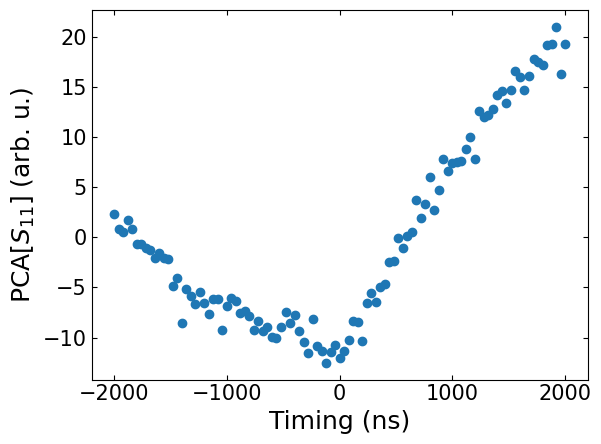

In [31]:
y = PCAtiming[0]
x = Fogi_timing

fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 15
ax1.set_xlabel('Timing (ns)', size='large')
ax1.set_ylabel('PCA[$S_{11}$] (arb. u.)', size='large')


ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")

plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

plt.scatter(x-2000, y)
plt.show()

In [ ]:
par_ini = {
    'amp': 50,
    'const':20,
    'center':850,
    'k':0.025
}

par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [ ]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

result = model.fit(data = -y, params=params, freq = x)
result

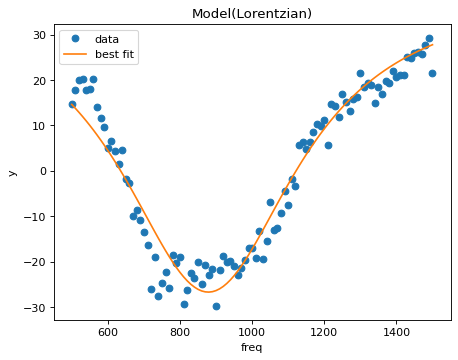

In [ ]:
fig, ax = plt.subplots(dpi=80)
result.plot_fit(ax = ax)
plt.show()

In [7]:
fogi_timing = "/2023-09-21/2023-09-21T172723_b0a8025c-td_ab_fogi_timing_sweep"
dd_fogi_timing = datadict_from_hdf5(header + fogi_timing +"/data")

ValueError: Specified file does not exist.

In [ ]:
x_timing = dd_fogi_timing['fogi_timing']['values']
y_timing = dd_fogi_timing['s11']['values'].imag

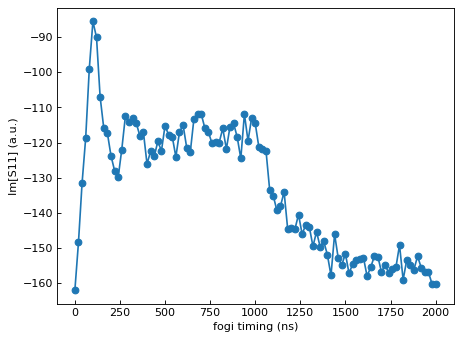

In [ ]:
fig, ax = plt.subplots(dpi=80)

#plt.title("fogi duration")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.plot(x_timing ,y_timing, marker = "o")

plt.xlabel("fogi timing (ns)")
plt.ylabel("Im[S11] (a.u.)")


plt.show()

photon amp

freq

In [ ]:
data1 = "/2023-09-20/2023-09-20T135505_ddc12220-td_ab_ph_freq_sweep"
dd1 = datadict_from_hdf5(header+data1+"/data")

dd1


s11: (1426,)
  ⌙ fogi_frequency (Hz): (1426,)
  ⌙ photon_frequency (Hz): (1426,)

In [ ]:
xs = []
ys = []

for i in range(31):
    ini = 46*i
    fin = 46*(1+i)
    x = dd1['fogi_frequency']['values'][ini:fin]
    ph = dd1['photon_frequency']['values'][ini:fin]
    y = dd1['s11']['values'][ini:fin].imag
    xs.append(x)
    ys.append(y)


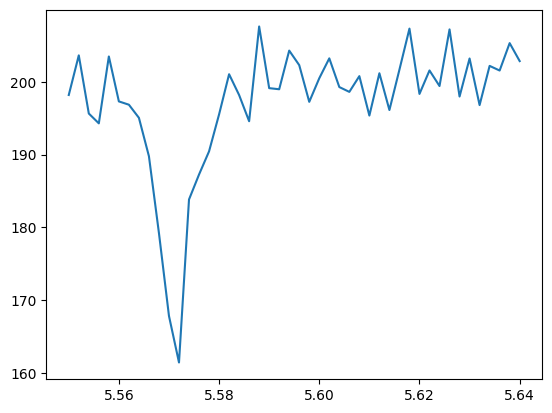

In [ ]:
plt.plot(xs[20], ys[20])
plt.show()

In [ ]:
timing = dd1['s11']['values']
#imag_ge = Rabi_ge.imag
Fogi_timing = dd1['fogi_timing']['values']

I = (timing.real)
Q = (timing.imag)

PCAfogi = PCA_transform(I, Q)
y = PCAfogi[0]
x = Fogi_timing

plt.plot(x, -y)
plt.show()

KeyError: 'fogi_timing'

In [ ]:

par_ini = {
    'amp': 50,
    'const':20,
    'center':850,
    'k':0.025
}

par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

result = model.fit(data = -y, params=params, freq = x)
result
fig, ax = plt.subplots(dpi=80)
result.plot_fit(ax = ax)
plt.show()

In [ ]:
data = "/2023-09-22/2023-09-22T141844_7ffc0276-td_ab_ph_freq_sweep"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['photon_frequency']['values']
y = dd['fogi_frequency']['values']
z = dd['s11']['values'].imag


In [ ]:
x1 = dd['fogi_frequency']['values'][21*10:21*11-1]
z1 = dd['s11']['values'][21*10:21*11-1].imag

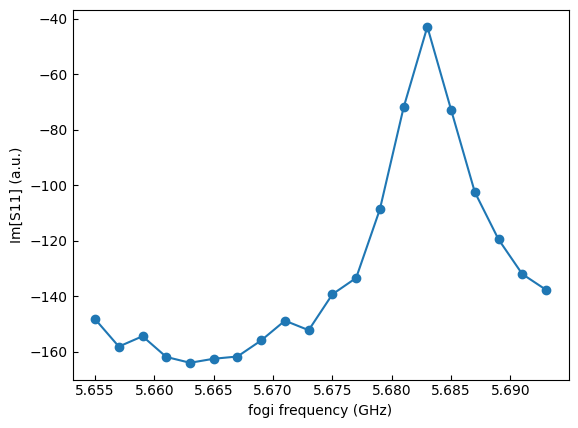

In [ ]:


plt.plot(x1, z1, marker = "o")
plt.xlabel("fogi frequency (GHz)")
plt.ylabel("Im[S11] (a.u.)")

#plt.xlim(5.671, 5.693)

plt.show()

C:\Users\qipe\AppData\Local\Temp\ipykernel_16152\1949104814.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('Blues')


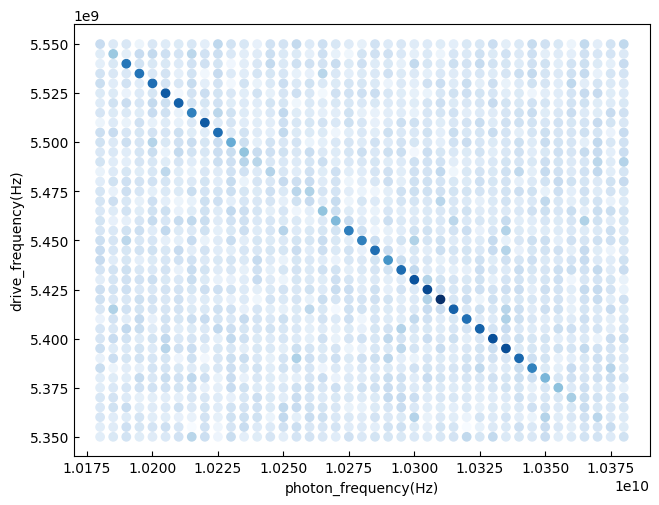

In [ ]:
cm = plt.cm.get_cmap('Blues')
fig= plt.figure()
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_xlabel("photon_frequency(Hz)")
ax.set_ylabel("drive_frequency(Hz)")

maingraph = ax.scatter(x, y, c=z, vmin=min(z), vmax=max(z), cmap=cm)
c = 
fig.colorbar(c)
plt.show()

C:\Users\qipe\AppData\Local\Temp\ipykernel_17332\2082817544.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('Blues')


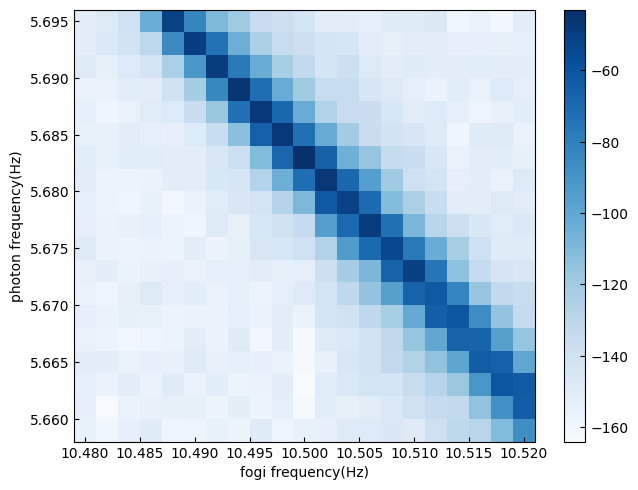

In [ ]:
cm = plt.cm.get_cmap('Blues')
fig= plt.figure()
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_xlabel("fogi frequency(Hz)")
ax.set_ylabel("photon frequency(Hz)")
ax.set_ylim(5.658, 5.696)

maingraph = ax.pcolormesh( np.unique(x),np.unique(y), z.reshape(21, 21).T, vmin=min(z), vmax=max(z), cmap=cm, shading='auto')
plt.colorbar(maingraph)
plt.show()

photon-fogi freq

In [ ]:
data2 = "/2023-09-22/2023-09-22T141844_7ffc0276-td_ab_ph_freq_sweep"
dd2 = datadict_from_hdf5(header+data2+"/data")

In [ ]:
dd2

s11: (441,)
  ⌙ fogi_frequency (Hz): (441,)
  ⌙ photon_frequency (Hz): (441,)

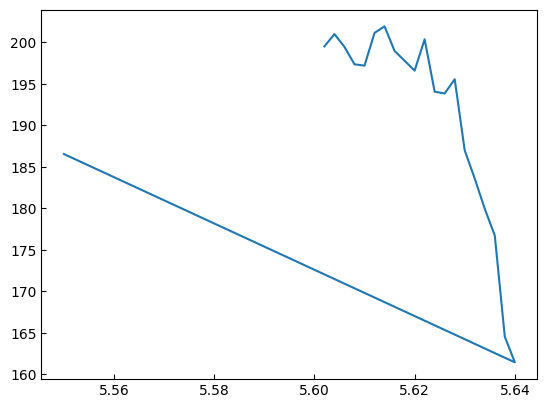

In [ ]:
xs = []
ys = []

for i in range(21):
    ini = 21*i
    fin = 21*(1+i)
    x = dd1['fogi_frequency']['values'][ini:fin]
    ph = dd1['photon_frequency']['values'][ini:fin]
    y = dd1['s11']['values'][ini:fin].imag
    xs.append(x)
    ys.append(y)

# plt.plot(xs[10], ys[10])
# plt.show()

In [ ]:
timing = dd1['s11']['values']
#imag_ge = Rabi_ge.imag
Fogi_timing = dd1['fogi_timing']['values']

I = (timing.real)
Q = (timing.imag)

PCAfogi = PCA_transform(I, Q)
y = PCAfogi[0]
x = Fogi_timing

plt.plot(x, -y)
plt.show()

In [ ]:
par_ini = {
    'amp': 50,
    'const':20,
    'center':850,
    'k':0.025
}

par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

result = model.fit(data = -y, params=params, freq = x)
result
fig, ax = plt.subplots(dpi=80)
result.plot_fit(ax = ax)
plt.show()
data = "/2023-09-20/2023-09-20T110244_c994cdb5-td_ab_ph_freq_sweep"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['photon_frequency']['values']
y = dd['fogi_frequency']['values']
z = dd['s11']['values'].imag


absorption rate - fogi & foton: square

In [7]:
header = "D:/K_sunada/result/CDY151/"
data = "/2023-11-13/2023-11-13T163810_9836839e-63_ab3_reflected_waveform"
#fogi: square, 1000ns, 0.9V, timing:photon+200ns
#photon: square, 1000ns, 0.08V

In [8]:
dd = datadict_from_hdf5(header+data+"/data")
dd

waveform: (1500,)
  ⌙ time (ns): (1500,)
waveform1: (1500,)
  ⌙ time (ns): (1500,)
waveform2: (1500,)
  ⌙ time (ns): (1500,)

In [9]:

x = dd['time']['values']
y = dd['waveform']['values']
y1 = dd['waveform1']['values']
y2 = dd['waveform2']['values']

In [20]:
def waveform_show(data):
    header = "D:/K_sunada/result/CDY151/"
    dd = datadict_from_hdf5(header+data+"/data")
    x = dd['time']['values']
    y = dd['waveform']['values']# - dd['waveform1']['values']
    y1 = dd['waveform1']['values']
    y2 = dd['waveform2']['values']

    plt.rcParams["font.size"] = 15

    fig, (ax0) = plt.subplots(nrows=1)
    # ax0.set_title("abosorption")
    ax0.set_xlabel('Time (ns)')
    ax0.set_ylabel('Waveform (V)')
    ax0.plot(x,  y)
    ax0.tick_params(axis="x", direction="in")
    ax0.tick_params(axis="y", direction="in")
    ax0.set_xlim( 0, 1000)
    ax0.set_ylim( -0.003, 0.004)

    fig, (ax1) = plt.subplots(nrows=1)
    # ax1.set_title("no absorption(zero fogi)")
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Waveform (V)')
    ax1.plot(x,  y1)
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")
    ax1.set_xlim( 0, 1000)    
    ax1.set_ylim(-0.003, 0.004)

    fig, (ax2) = plt.subplots(nrows=1)
    # ax2.set_title("noise(zero fogi & photon)")
    ax2.set_xlabel('Time (ns)')
    ax2.set_ylabel('Waveform (V)')
    ax2.plot(x,  y2)
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")
    ax2.set_xlim( 0, 1000)
    ax2.set_ylim(-0.003, 0.004)

    plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
    plt.show()

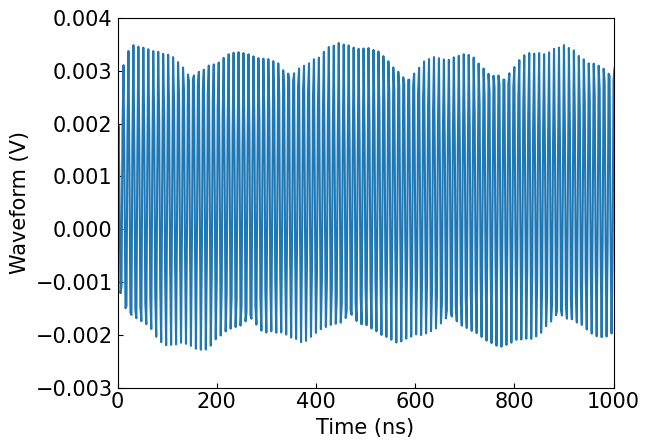

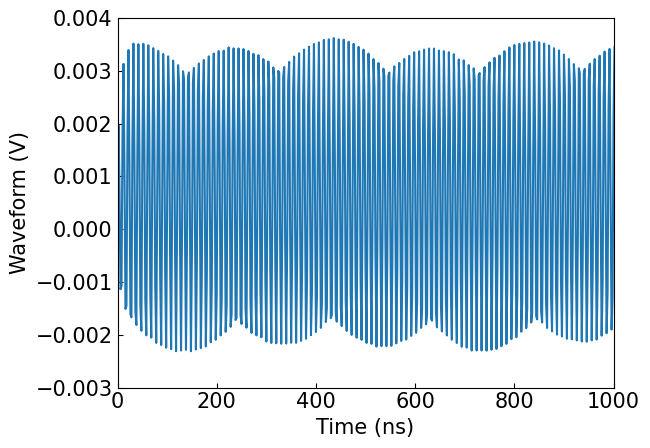

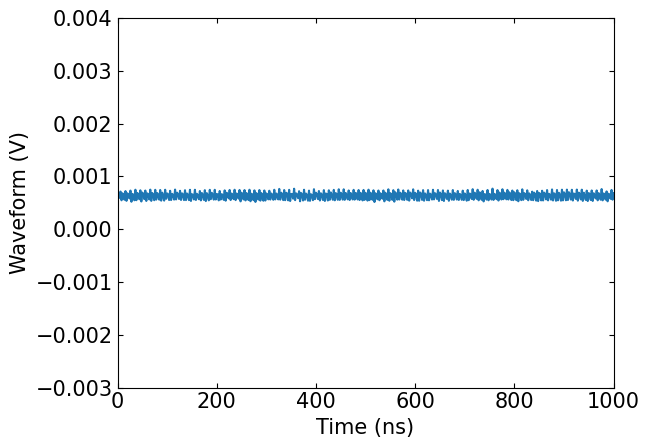

In [21]:
waveform_show(data)

In [41]:
def photon_energy(data):
    header = "D:/K_sunada/result/CDY151/"
    dd = datadict_from_hdf5(header+data+"/data")
    x = dd['time']['values']
    y = dd['waveform']['values'] #- dd['waveform1']['values']
    y1 = dd['waveform1']['values']
    y2 = dd['waveform2']['values']
    offset=np.mean(y)
    offset1=np.mean(y1)
    offset2=np.mean(y2)
    E = 0
    E1 = 0
    E2 = 0
    for t in range(len(x)):
        E = E + ((y[t]-offset)**2)*2
        E1 = E1 + ((y1[t]-offset1)**2)*2
        E2 = E2 + ((y2[t]-offset2)**2)*2

    rate = 1 - (E-E2)/(E1-E2)

    return E, E1, E2, rate

In [42]:
photon_energy(data)

(0.011535580395706034,
 0.012291348906978418,
 1.676222804955248e-05,
 0.06157180938481388)

In [ ]:
data1 = "/2023-09-22/2023-09-22T143739_24d1513f-td_ab_reflection"
#fogi: square, 1000ns, 0.9V, timing:photon-830ns
#photon: square, 800ns, 0.03V

In [ ]:
photon_energy(data1)

(0.0001484211017742668,
 0.00014444179349968998,
 1.1451166102956378e-07,
 -0.02757142117472422)

In [ ]:
data2 = "/2023-09-21/2023-09-21T094857_a5b6aa1b-td_ab_reflection"
#fogi: square, 1000ns, 0.9V, timing:photon+0ns
#photon: square, 1000ns, 0.08V
photon_energy(data2)

(6.708595315767448e-05,
 6.759169243846019e-05,
 1.6609447137365717e-07,
 0.007500701455144476)

absorption rate - fogi: square & photon: time reversed

In [ ]:
data = "/2023-09-21/2023-09-21T102917_480c9226-td_photon_generation"
#fogi: square, 1000ns, 0.9V

dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values']
y = dd['waveform']['values']



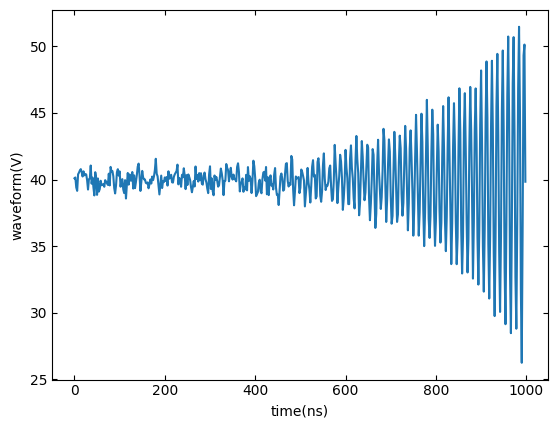

In [ ]:
fig, (ax0) = plt.subplots(nrows=1)
ax0.set_xlabel('time(ns)')
ax0.set_ylabel('waveform(V)')
ax0.plot(x,  y[::-1])
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
#    ax0.set_ylim(-0.0005, 0.0017)

plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
plt.show()

In [ ]:
header = "D:/K_sunada/result/CDY148/"
data_ph = "/2023-09-21/2023-09-21T102917_480c9226-td_photon_generation"
dd = datadict_from_hdf5(header+data_ph+"/data")
y_ph = dd['waveform']['values']

def y_lerp(y): #sennkeihokann
    y_new = []
    for i in range(len(y)-1):
        y_new.append(y[i])
        y_new.append((y[i]+y[i+1])/2)
    y_new.append(y[len(y)-1])
    return y_new-np.mean(y)

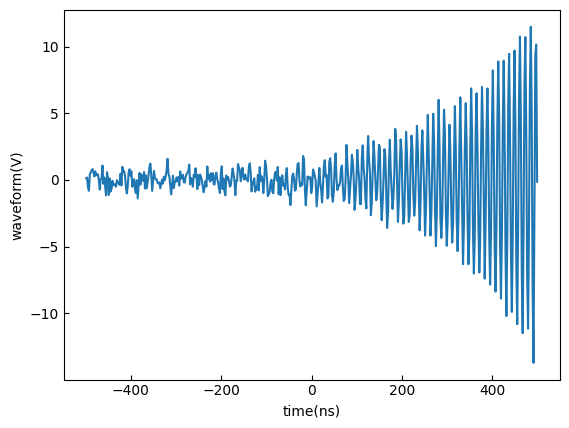

In [ ]:
fig, (ax0) = plt.subplots(nrows=1)
ax0.set_xlabel('time(ns)')
ax0.set_ylabel('waveform(V)')
ax0.plot(y_lerp(x),  y_lerp(y_ph[::-1]))
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")

plt.show()